# Module 5.A - Linear Models on NYC 311 (Regression Baselines)

# Module 5.A — Linear Models on NYC 311 (Regression Baselines)

This lab builds **strong, interpretable regression baselines** on the NYC 311 feature table:

- Load the normalized feature table from earlier modules
- Define target: **resolution time** (`resolution_hours`)
- Split correctly (**random**, not time-based, due to right-censoring in this 6-day slice)
- Baseline: **Linear Regression** with standardized features
- Regularize: **Ridge** and **Lasso** (tune α on validation)
- Evaluate: **RMSE** (and **MAE** for robustness intuition)
- Interpret: coefficient signs, magnitude, and stability
- Deliverable: a short narrative — *“what matters most and why I trust it”*

> **Baseline discipline:** If you can’t beat a linear model, your pipeline likely needs better data, features, or evaluation.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 4A.1 - Load the Normalized NYC 311 Feature Table

In [2]:
CANDIDATES = [
    Path("work/m3/data/nyc311_features_norm.parquet"),
]

path = next((p for p in CANDIDATES if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        "Could not find nyc311_features_norm.parquet. "
        "Expected one of:\n" + "\n".join(str(p) for p in CANDIDATES)
    )

df = pd.read_parquet(path)
print("Loaded:", path)
print("Shape:", df.shape)
display(df.head(3))

Loaded: work/m3/data/nyc311_features_norm.parquet
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,...,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,<NA>,other,1,...,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,...,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,...,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


## 4A.2 - Define target + define a “safe” feature set (leakage-aware)

### Target: `resolution_hours`
- If a request is still open, `resolution_hours` is missing.
- For supervised learning we need **known outcomes**, so we will train on rows where `resolution_hours` is not null.

### Leakage awareness (important)
This feature table includes columns that *might* encode information too close to the target:

- `status`, `is_closed`: these trivially reveal whether resolution time is even defined
- aggregate columns like `median_resolution_hours`, `agency_median_resolution`, etc. may have been computed using outcomes (depending on how they were built)

We will train two versions:
1. **SAFE**: excludes obvious outcome/aggregate leakage columns  
2. **ALL**: includes everything except identifiers and timestamps (useful as a diagnostic)

If the ALL model is dramatically better, that’s a warning sign that you’re benefiting from leakage-like features.


In [3]:
TARGET = "resolution_hours"

# ------------------------------------------------------------
# Clean the FULL table first (so other sections can reuse it)
# ------------------------------------------------------------
df_clean = df.copy()

# Convert all pandas string dtype columns to object strings with explicit missing token
string_cols = [c for c in df_clean.columns if "string" in str(df_clean[c].dtype)]
for c in string_cols:
    df_clean[c] = df_clean[c].fillna("(missing)").astype(str)

# Convert pandas nullable integer dtype to float
nullable_int_cols = [c for c in df_clean.columns if str(df_clean[c].dtype) == "Int64"]
for c in nullable_int_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce").astype(float)

# --- Fix: pandas NA in boolean-like columns ---
# Convert nullable boolean / bool-ish flags into 0/1 integers with missing -> 0
bool_like_cols = []
for c in df_clean.columns:
    if str(df_clean[c].dtype) in ["boolean", "bool"]:
        bool_like_cols.append(c)

# Also include common 0/1 flags that sometimes get loaded oddly
for c in ["is_weekend", "zip_missing", "is_closed"]:
    if c in df_clean.columns and c not in bool_like_cols:
        if str(df_clean[c].dtype) in ["object", "string", "boolean", "bool"]:
            bool_like_cols.append(c)

bool_like_cols = sorted(set(bool_like_cols))
print("Normalizing bool-like cols:", bool_like_cols)

for c in bool_like_cols:
    df_clean[c] = df_clean[c].fillna(False).astype(int)

# ------------------------------------------------------------
# Regression dataset: keep only rows with known outcomes
# ------------------------------------------------------------
df_model = df_clean[df_clean[TARGET].notna()].copy()
print("Rows with known target:", df_model.shape[0], "out of", df_clean.shape[0])

# Columns you should NOT use as predictors
ID_COLS = ["unique_key", "_source"]
TIME_COLS = ["created_date", "created_day"]  # keep created_hour/dayofweek as engineered time features
OUTCOME_REVEALERS = ["status", "is_closed"]  # can leak outcome availability / state

# "Aggregate-ish" columns that are suspicious for leakage (depends on how they were constructed)
AGG_COLS = [
    "closed_rate",
    "median_resolution_hours",
    "agency_n_requests",
    "agency_closed_rate",
    "agency_median_resolution",
]

# A "safe-ish" feature set: engineered but not obviously target-derived
SAFE_DROP = set(ID_COLS + TIME_COLS + OUTCOME_REVEALERS + AGG_COLS + [TARGET])

# The "all features" set: only drop identifiers, timestamps, and explicit outcome columns
ALL_DROP = set(ID_COLS + TIME_COLS + OUTCOME_REVEALERS + [TARGET])

safe_features = [c for c in df_model.columns if c not in SAFE_DROP]
all_features = [c for c in df_model.columns if c not in ALL_DROP]

print("SAFE feature count:", len(safe_features))
print("ALL feature count:", len(all_features))

# Quick sanity check
missing_safe = [c for c in SAFE_DROP if c in df_model.columns]
print("\nDropped (SAFE):", sorted(missing_safe))


Normalizing bool-like cols: []
Rows with known target: 19617 out of 50000
SAFE feature count: 13
ALL feature count: 18

Dropped (SAFE): ['_source', 'agency_closed_rate', 'agency_median_resolution', 'agency_n_requests', 'closed_rate', 'created_date', 'created_day', 'is_closed', 'median_resolution_hours', 'resolution_hours', 'status', 'unique_key']


## 5A.3 - Write Reusable Preprocessing Artifacts

To avoid repeating the same “table hygiene” work in later notebooks,
we will save:

- **A cleaned version of the full table** (`df_clean`) with consistent dtypes  
- A **feature configuration** (SAFE/ALL drop lists + the SAFE feature names used for modeling)

Later notebooks can load these artifacts and focus on *modeling* instead of redoing
dtype normalization and leakage bookkeeping.

In [4]:
import os, json
from pathlib import Path

# Choose a stable artifacts directory (create if missing)
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save cleaned full table (includes open cases; resolution_hours may be missing)
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
df_clean.to_parquet(clean_path, index=False)

# 2) Save feature config + SAFE feature list (for regression modeling)
config = {
    "target_regression": TARGET,
    "id_cols": ID_COLS,
    "time_cols": TIME_COLS,
    "outcome_revealers": OUTCOME_REVEALERS,
    "agg_cols_suspect": AGG_COLS,
    "safe_drop": sorted(list(SAFE_DROP)),
    "all_drop": sorted(list(ALL_DROP)),
    "safe_features_regression": safe_features,   # feature names used for A (regression)
    "all_features_regression": all_features,
    "notes": [
        "df_clean contains all rows with dtype normalization applied (strings, bool-like flags, nullable ints).",
        "SAFE_DROP is leakage-aware but still a heuristic—revisit if you change feature definitions upstream.",
        "Later notebooks (e.g., 5.B) can load df_clean + safe_drop/all_drop and define their own targets."
    ],
}
config_path = ARTIFACT_DIR / "feature_config.json"
config_path.write_text(json.dumps(config, indent=2))

print("Wrote artifacts to:", ARTIFACT_DIR)
print(" -", clean_path)
print(" -", config_path)


Wrote artifacts to: work/m5/artifacts/nyc311
 - work/m5/artifacts/nyc311/nyc311_features_clean.parquet
 - work/m5/artifacts/nyc311/feature_config.json


## 5A.4 - Split Train/Validation/Test (random)

Because this dataset only spans ~6 days, **time splits** can create severe right-censoring in the test set (many open requests).
So we use a **random split**:

- Train: 70%
- Validation: 15%
- Test: 15%

> We’ll keep the test set untouched until final evaluation.

In [5]:
RANDOM_STATE = 42

def make_splits(df_in: pd.DataFrame, feature_cols: list[str]):
    X = df_in[feature_cols].copy()
    y = df_in[TARGET].astype(float).copy()

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

Xtr_s, Xva_s, Xte_s, ytr, yva, yte = make_splits(df_model, safe_features)
print("SAFE splits:", Xtr_s.shape, Xva_s.shape, Xte_s.shape)

Xtr_a, Xva_a, Xte_a, _, _, _ = make_splits(df_model, all_features)
print("ALL splits :", Xtr_a.shape, Xva_a.shape, Xte_a.shape)

SAFE splits: (13731, 13) (2943, 13) (2943, 13)
ALL splits : (13731, 18) (2943, 18) (2943, 18)


## 5A.5 - Preprocessing: Numeric Scaling + Categorical Encoding  

Linear models care about feature scale, especially when regularized.

We will:
- **Standardize numeric columns** (mean 0, std 1)
- **One-hot encode categorical columns**
- **Impute missing values**
- Build a single `Pipeline` so preprocessing is applied consistently to train/val/test

In [6]:
from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    # Treat ONLY true numeric/bool as numeric
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c])]
    
    # Anything else becomes categorical EXCEPT datetimes (we'll drop by default)
    dt_cols  = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),  # or constant="(missing)"
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

pre_safe = build_preprocessor(Xtr_s)
pre_all  = build_preprocessor(Xtr_a)

def describe_cols(X):
    from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype
    num_cols = [c for c in X.columns if (is_numeric_dtype(X[c]) or is_bool_dtype(X[c]))]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

n_s, c_s, d_s = describe_cols(Xtr_s)
n_a, c_a, d_a = describe_cols(Xtr_a)

print("SAFE:", len(n_s), "numeric |", len(c_s), "categorical |", len(d_s), "datetime dropped")
print("ALL :", len(n_a), "numeric |", len(c_a), "categorical |", len(d_a), "datetime dropped")
print("\nExample categorical cols:", c_s[:10])
pre_safe.fit_transform(Xtr_s).shape

SAFE: 10 numeric | 3 categorical | 0 datetime dropped
ALL : 15 numeric | 3 categorical | 0 datetime dropped

Example categorical cols: ['agency', 'borough_norm', 'complaint_topk']


(13731, 44)

## 5A.6 - Baseline Model: Linear Regression


We fit:
- Linear Regression (no regularization)

Then we evaluate on:
- Validation (for model selection)
- Test (final report)

In [7]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred) -> float:
    return float(mean_absolute_error(y_true, y_pred))

def fit_and_eval(pre, model, Xtr, ytr, Xva, yva, Xte, yte):
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(Xtr, ytr)

    out = {
        "val_rmse": rmse(yva, pipe.predict(Xva)),
        "val_mae": mae(yva, pipe.predict(Xva)),
        "test_rmse": rmse(yte, pipe.predict(Xte)),
        "test_mae": mae(yte, pipe.predict(Xte)),
        "pipeline": pipe,
    }
    return out

lin_safe = fit_and_eval(pre_safe, LinearRegression(), Xtr_s, ytr, Xva_s, yva, Xte_s, yte)
lin_all  = fit_and_eval(pre_all,  LinearRegression(), Xtr_a, ytr, Xva_a, yva, Xte_a, yte)

pd.DataFrame([
    {"feature_set": "SAFE", "model": "LinearRegression", **{k:v for k,v in lin_safe.items() if k.endswith(("rmse","mae"))}},
    {"feature_set": "ALL",  "model": "LinearRegression", **{k:v for k,v in lin_all.items()  if k.endswith(("rmse","mae"))}},
]).sort_values(["feature_set"])


,feature_set,model,val_rmse,val_mae,test_rmse,test_mae
1,ALL,LinearRegression,8.292098,5.371471,8.330838,5.485786
0,SAFE,LinearRegression,8.306452,5.448076,8.330231,5.555259


## 5A.7 - Regularization: Tune Ridge and Lasso on Validation

We will tune α (called `alpha` in scikit-learn) using the validation set.

- Ridge: stable default under collinearity
- Lasso: can drive some coefficients to exactly zero (implicit feature selection)

> Because Lasso optimizes an L1 penalty, it can require more iterations (`max_iter`) to converge.

In [8]:
ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

def tune_alpha(pre, model_class, model_kwargs, Xtr, ytr, Xva, yva):
    rows = []
    best = None
    for a in ALPHAS:
        model = model_class(alpha=a, **model_kwargs)
        pipe = Pipeline([("pre", pre), ("model", model)])
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xva)
        row = {"alpha": a, "val_rmse": rmse(yva, pred), "val_mae": mae(yva, pred)}
        rows.append(row)
        if best is None or row["val_rmse"] < best["val_rmse"]:
            best = {**row, "pipeline": pipe}
    return pd.DataFrame(rows).sort_values("val_rmse"), best

ridge_table_safe, ridge_best_safe = tune_alpha(pre_safe, Ridge, {}, Xtr_s, ytr, Xva_s, yva)
lasso_table_safe, lasso_best_safe = tune_alpha(pre_safe, Lasso, {"max_iter": 5000}, Xtr_s, ytr, Xva_s, yva)

ridge_table_all, ridge_best_all = tune_alpha(pre_all, Ridge, {}, Xtr_a, ytr, Xva_a, yva)
lasso_table_all, lasso_best_all = tune_alpha(pre_all, Lasso, {"max_iter": 5000}, Xtr_a, ytr, Xva_a, yva)

print("SAFE — Ridge (top rows):")
display(ridge_table_safe.head(5))
print("SAFE — Lasso (top rows):")
display(lasso_table_safe.head(5))


SAFE — Ridge (top rows):


,alpha,val_rmse,val_mae
3,10.00,8.304696,5.452338
2,1.00,8.305206,5.447879
1,0.10,8.306341,5.447957
0,0.01,8.306414,5.447919
4,100.00,8.329978,5.514146


SAFE — Lasso (top rows):


,alpha,val_rmse,val_mae
0,0.01,8.308819,5.451834
1,0.10,8.468491,5.650177
2,1.00,9.183417,6.169117
3,10.00,12.692893,9.624261
4,100.00,12.692893,9.624261


## 5A.8 - Final Evaluation on the Test Set

Now we evaluate the best Ridge and Lasso models on the untouched set.  

We will report:  
* RMSE (penalizes large errors)
* MAE (more robust; median-ish intuition)

Then we will compare SAFE vs ALL to see if suspicious features are inflating performance

In [9]:
def eval_best(best, Xte, yte):
    pipe = best["pipeline"]
    return {
        "alpha": best["alpha"],
        "test_rmse": rmse(yte, pipe.predict(Xte)),
        "test_mae": mae(yte, pipe.predict(Xte)),
        "pipeline": pipe,
    }

ridge_safe = eval_best(ridge_best_safe, Xte_s, yte)
lasso_safe = eval_best(lasso_best_safe, Xte_s, yte)

ridge_all = eval_best(ridge_best_all, Xte_a, yte)
lasso_all = eval_best(lasso_best_all, Xte_a, yte)

rows = [
    {"feature_set": "SAFE", "model": "LinearRegression", "alpha": None, **{k:v for k,v in lin_safe.items() if k.startswith("test_")}},
    {"feature_set": "SAFE", "model": "Ridge", "alpha": ridge_safe["alpha"], "test_rmse": ridge_safe["test_rmse"], "test_mae": ridge_safe["test_mae"]},
    {"feature_set": "SAFE", "model": "Lasso", "alpha": lasso_safe["alpha"], "test_rmse": lasso_safe["test_rmse"], "test_mae": lasso_safe["test_mae"]},

    {"feature_set": "ALL", "model": "LinearRegression", "alpha": None, **{k:v for k,v in lin_all.items() if k.startswith("test_")}},
    {"feature_set": "ALL", "model": "Ridge", "alpha": ridge_all["alpha"], "test_rmse": ridge_all["test_rmse"], "test_mae": ridge_all["test_mae"]},
    {"feature_set": "ALL", "model": "Lasso", "alpha": lasso_all["alpha"], "test_rmse": lasso_all["test_rmse"], "test_mae": lasso_all["test_mae"]},
]

results = pd.DataFrame(rows).sort_values(["feature_set","test_rmse"])
results


,feature_set,model,alpha,test_rmse,test_mae
4,ALL,Ridge,1.00,8.330339,5.486360
3,ALL,LinearRegression,NaN,8.330838,5.485786
5,ALL,Lasso,0.01,8.355824,5.504601
0,SAFE,LinearRegression,NaN,8.330231,5.555259
1,SAFE,Ridge,10.00,8.331529,5.565459
2,SAFE,Lasso,0.01,8.331918,5.562993


## 5A.9 - Diagnostic: is ALL "too good to be true"?  

If ALL features are much better than SAFE, you should ask:

- Are aggregate features computed using future information?
- Are there columns that directly encode the outcome?
- Would these features exist at prediction time?

This is not about being “pure.” It’s about building models that survive reality.

In [10]:
# A simple “gap” view
def summarize_gap(df_results: pd.DataFrame):
    pivot = df_results.pivot_table(index="model", columns="feature_set", values="test_rmse")
    pivot["ALL_minus_SAFE"] = pivot.get("ALL", np.nan) - pivot.get("SAFE", np.nan)
    return pivot.sort_values("SAFE")

summarize_gap(results)


feature_set,ALL,SAFE,ALL_minus_SAFE
model,,,
LinearRegression,8.330838,8.330231,0.000607
Ridge,8.330339,8.331529,-0.001190
Lasso,8.355824,8.331918,0.023906


## 5A.10 - Interpret Coefficients (What the Linear Model Learned)

We’ll inspect coefficients from the **best Ridge model** (usually the most stable under collinearity).

Important interpretation notes:
- Numeric coefficients are in “per 1 standard deviation of the feature” units (because we standardized)
- One-hot coefficients are relative offsets vs the omitted baseline category
- Correlated features can still share / split weight

We’ll list the largest positive and negative coefficients as a starting point.


In [11]:
def get_feature_names(pipe: Pipeline) -> np.ndarray:
    pre = pipe.named_steps["pre"]
    return pre.get_feature_names_out()

def top_coefficients(pipe: Pipeline, top_k: int = 15):
    model = pipe.named_steps["model"]
    names = get_feature_names(pipe)
    coefs = model.coef_.ravel()
    s = pd.Series(coefs, index=names).sort_values()
    return s.head(top_k), s.tail(top_k)

ridge_pipe_safe = ridge_safe["pipeline"]
neg, pos = top_coefficients(ridge_pipe_safe, top_k=12)

print("Top NEGATIVE coefficients (predict faster resolution):")
display(neg.to_frame("coef"))

print("Top POSITIVE coefficients (predict slower resolution):")
display(pos.to_frame("coef"))

Top NEGATIVE coefficients (predict faster resolution):


,coef
agency_NYPD,-10.128821
agency_DOB,-9.898583
complaint_topk_heat/hot water,-6.971340
complaint_topk_traffic signal condition,-6.911553
complaint_topk_water system,-3.175747
agency_DEP,-2.136320
agency_DOE,-1.817075
created_dow,-1.416787
dayofweek,-1.416787
complaint_topk_noise - residential,-1.211964


Top POSITIVE coefficients (predict slower resolution):


,coef
complaint_topk_general,1.201826
borough_norm_STATEN ISLAND,1.249253
borough_norm_(missing),1.601626
complaint_topk_door/window,1.706857
complaint_topk_unsanitary condition,2.258990
complaint_topk_homeless person assistance,2.740132
complaint_topk_plumbing,2.880394
complaint_topk_water leak,3.126244
agency_TLC,3.373991
agency_DCWP,5.424475


## 5A.11 - Coefficient Stability Check

A coefficient list is only useful if it’s reasonably stable.

We’ll do a small stability check:
- Refit the same Ridge configuration on several random train/val splits
- Track how often the “top features” appear

This is not a full scientific procedure — it’s a production-style sanity check.


In [12]:
def refit_ridge_and_get_top_features(df_in, feature_cols, alpha, n_runs=6, top_k=12, seed0=0):
    counts = {}
    for i in range(n_runs):
        rs = seed0 + i
        Xtr, Xva, Xte, ytr_, yva_, yte_ = make_splits(df_in, feature_cols)
        pre = build_preprocessor(Xtr)
        pipe = Pipeline([("pre", pre), ("model", Ridge(alpha=alpha))])
        pipe.fit(Xtr, ytr_)
        names = pipe.named_steps["pre"].get_feature_names_out()
        coefs = pipe.named_steps["model"].coef_.ravel()
        s = pd.Series(coefs, index=names)

        top = pd.concat([s.abs().sort_values(ascending=False).head(top_k)]).index.tolist()
        for f in top:
            counts[f] = counts.get(f, 0) + 1

    out = pd.Series(counts).sort_values(ascending=False).to_frame("appearances_in_topK")
    out["pct"] = out["appearances_in_topK"] / n_runs
    return out

alpha_star = ridge_safe["alpha"]
stab = refit_ridge_and_get_top_features(df_model, safe_features, alpha=alpha_star, n_runs=6, top_k=12)
display(stab.head(20))

print(f"Interpretation: features with pct near 1.0 show up consistently across refits (more trustworthy).")


,appearances_in_topK,pct
agency_HPD,6,1.0
agency_NYPD,6,1.0
agency_DOB,6,1.0
complaint_topk_snow or ice,6,1.0
complaint_topk_heat/hot water,6,1.0
complaint_topk_traffic signal condition,6,1.0
agency_DCWP,6,1.0
agency_TLC,6,1.0
complaint_topk_water system,6,1.0
complaint_topk_water leak,6,1.0


Interpretation: features with pct near 1.0 show up consistently across refits (more trustworthy).


## 5A.12 - Deliverable  

Write 6-10 bullets.  
1. **Baseline quality:** Which model did best (Linear vs Ridge vs Lasso), and by how much?
2. **Leakage suspicion:** Did ALL features outperform SAFE dramatically? What might explain that?
3. **What matters:** Name 3-5 influential features (from coefficients). Explain directionally why they make sense
4. **Trust:** Which coefficients do you trust the most, and why? (stability, domain logic, leakage checks)
5. **Next iteration:** If you had one more hour, what would you change? (feature, transform, target, evaluation)

### My responses
1. **Baseline Quality:** Based on 5A.8 - The model that performed the best was the Ridge model on the ALL feature set with an alpha of 1.00. It barely performed better than others. They were all pretty similar
2. **Leakage suspicion:** Based on 5A.0. The leakage suspicion is low. Both the SAFE and ALL feature sets performed similarly.
3. **What matters:** (5A.10)  
    * **HPD** - This agency contained the slowest resolving cases
    * **NYPD** - This agency contained the fastest resolving cases
    * **Snow/Ice** - This was the longest complaint type
    * **Heat/Hot Water** - This was the fastest complaint type
4. **Trust:** (5A.11) - All of the features appeared in 100% of the 6 independent refits. They are all trustworthy
5. **Next iteration:** It seems like these models are performing quite well. With more time I would investigate the 30k dropped rows with unknown resolution time (5A.2). That is a significant amount. 

# Module 5B - NYC 311 Classification Baselines

**Logistic Regression + kNN + Thresholding**

In this notebook you will build **classification** baselines using the NYC 311 feature table prepared in **Module 5.A**.

You will:
- Load the artifacts created in 5.A  
- Define a **binary target** (classification)  
- Split **randomly** into train/validation/test (this dataset covers ~6 days → temporal splits would add heavy right-censoring)  
- Train a **logistic regression** baseline (with standardization + one-hot encoding)  
- Tune **thresholds** and evaluate with decision-aware metrics (precision/recall/F1)  
- Train a **kNN** baseline (with scaling + dimensionality reduction) and tune **k**  
- Interpret **what features push probability up/down**  
- Write a short narrative: *“what matters most and why I trust it.”*

---

## Important note about censoring 
This dataset includes both **closed** and **open** cases.  
- If you predict **`is_closed`**, open cases are labeled `0` at extraction time — some may close later (label noise / censoring).  
- If you predict **“closed within 24h”**, open cases are **unknown** (censored), unless you restrict to already-closed cases.

We will:
1) Use **`is_closed`** as the primary target (simple, realistic baseline).  
2) Optionally define **`closed_within_24h`** on **closed-only** rows as a second exercise.

Random splits reduce time-based artifacts, but you still must think about **what the label actually means**.

In [13]:
# === Setup ===
import os, json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

SEED = 42
rng = np.random.default_rng(SEED)

## 5B.1 - Load Artifacts from Module 5A

In [14]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
config_path = ARTIFACT_DIR / "feature_config.json"

paths_tried = []

def load_df():
    global paths_tried
    if clean_path.exists():
        paths_tried.append(str(clean_path))
        return pd.read_parquet(clean_path), "m5_artifact_clean"
    raise FileNotFoundError(
        "Could not find NYC 311 artifacts. Tried:\n" + "\n".join(paths_tried + [str(clean_path), str(fallback_m3)])
    )

df, df_source = load_df()
print("Loaded source:", df_source)
print("Shape:", df.shape)
display(df.head(3))

Loaded source: m5_artifact_clean
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,1,0,0,NaN,280,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,0,0,0,911.0,280,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,1,0,0,936.0,280,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [15]:
# Load config
config = None
if config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config keys:", sorted(list(config.keys())))
    print("target_regression:", config.get("target_regression"))
else:
    print("No feature_config.json found at:", config_path)


Loaded config keys: ['agg_cols_suspect', 'all_drop', 'all_features_regression', 'id_cols', 'notes', 'outcome_revealers', 'safe_drop', 'safe_features_regression', 'target_regression', 'time_cols']
target_regression: resolution_hours


## 5B.2 - Define a Classification Target  

### Primary target: `is_closed`  
This is a realistic classification task:  
"given the features we have at request time, predict whether the ticket is already closed at extraction time."

### Optional target: `closed_within_24h`  
For a cleaner "within 24h" label, restrict to rows where `resolution_hours` is known. That turns the problem into:
"among closed cases, which ones resolved quickly?"  

**Implement both and choose which to run**

In [16]:
# === Choose target ===
# Options:
# TARGET = "is_closed"
TARGET = "closed_within_24h_closed_only"

df = df.copy()

# Basic sanity checks
assert "is_closed" in df.columns, "Expected column is_closed"
if "resolution_hours" not in df.columns:
    print("Note: resolution_hours missing in this table. closed_within_24h mode will not work.")

if TARGET == "is_closed":
    df_model = df.copy()
    df_model[TARGET] = df_model["is_closed"].astype(int)

elif TARGET == "closed_within_24h_closed_only":
    if "resolution_hours" not in df.columns:
        raise ValueError("resolution_hours not found; cannot compute closed_within_24h")

    # closed-only to avoid censoring
    df_model = df[df["resolution_hours"].notna()].copy()
    df_model[TARGET] = (df_model["resolution_hours"] <= 24).astype(int)

else:
    raise ValueError("Unknown TARGET")

print("TARGET column:", TARGET)
print("Model rows:", len(df_model))
print("Positive rate:", float(df_model[TARGET].mean()))


TARGET column: closed_within_24h_closed_only
Model rows: 19617
Positive rate: 0.8583881327420095


### Analysis:  

* `is_closed` - Model rows: 50000, Positive rate: 0.37788
* `closed_within_24h` - Model rows: 19617, Positive rate: 0.858388

The tests revealed that `is_closed` is moderately imbalanced, while `closed within_24` has a larger imbalance.  

I decided to go with `closed_within_24` as another project I am working on has a very large imbalance and I want to look more into it.

## 5B.3 - Leakage Checks: SAFE vs ALL feature sets  
Classification can be especially sensitive to leakage because any "post-outcome" information makes the task trivial.  

We will:  
* build a **SAFE** feature list (drop obvious outcome revealers)
* optionally compare to an **ALL** feature set (to show how leakage can inflate metrics)

We will use `feature_config.json` if available, and also apply a few classification-specific drops.

In [17]:
# === Build feature lists (from 5.A config) ===

import json
from pandas.api.types import is_datetime64_any_dtype

# Load config (no fallback)
config = json.loads(config_path.read_text())

# Start from config drops
safe_drop = set(config["safe_drop"])
all_drop  = set(config["all_drop"])

# Classification-specific: never include target or direct revealers
# (even if upstream config changes later)
safe_drop |= {"is_closed", "status", "resolution_hours", TARGET}
all_drop  |= {"is_closed", "resolution_hours", TARGET}  # keep status in ALL if you want to demonstrate leakage, but never keep target

# Optional: drop datetime columns by default (preprocessor drops them anyway)
dt_cols = [c for c in df_model.columns if is_datetime64_any_dtype(df_model[c])]
safe_drop |= set(dt_cols)
all_drop  |= set(dt_cols)

def build_feature_list(df_in, drop_cols):
    feature_cols = [c for c in df_in.columns if c not in drop_cols]
    return feature_cols

safe_features = build_feature_list(df_model, safe_drop)
all_features  = build_feature_list(df_model, all_drop)

print("SAFE features:", len(safe_features))
print("ALL  features:", len(all_features))

print("\nExamples of dropped columns (SAFE):")
safe_drop_sorted = sorted(list(safe_drop))
print(safe_drop_sorted[:25], "..." if len(safe_drop_sorted) > 25 else "")

print("\nPreview SAFE feature columns:")
print(safe_features[:15])

SAFE features: 13
ALL  features: 18

Examples of dropped columns (SAFE):
['_source', 'agency_closed_rate', 'agency_median_resolution', 'agency_n_requests', 'closed_rate', 'closed_within_24h_closed_only', 'created_date', 'created_day', 'is_closed', 'median_resolution_hours', 'resolution_hours', 'status', 'unique_key'] 

Preview SAFE feature columns:
['created_hour', 'dayofweek', 'is_weekend', 'agency', 'borough_norm', 'complaint_topk', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


## 5B.4 - Split Train/Val/Test (random, stratified)  

Because the dataset spans only ~6 days and has right-censoring issues, **do NOT** do temporal splits here, random is better.  

Since this is a classification task, we also use **stratification** so that the positive rate stays similar in train/val/test. This makes comparisons across models and thresholds more stable.  

We will use: 
* Train: 70%
* Validation: 15%
* Test: 15%

In [18]:
# === Random split (stratified) ===
# NOTE: We stratify so train/val/test have similar positive rates.

RANDOM_STATE = 42  

def make_splits(df_in: pd.DataFrame, feature_cols: list[str]):
    X = df_in[feature_cols].copy()
    y = df_in[TARGET].astype(int).copy()

    # 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )

    # split temp into 15% val, 15% test (half of 30%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def rate(a): 
    return float(np.mean(a))

# SAFE splits
Xtr_s, Xva_s, Xte_s, ytr, yva, yte = make_splits(df_model, safe_features)
print("SAFE splits:", Xtr_s.shape, Xva_s.shape, Xte_s.shape)
print("SAFE positive rates:", rate(ytr), rate(yva), rate(yte))

# ALL splits (same function, same RANDOM_STATE)
Xtr_a, Xva_a, Xte_a, ytr_a, yva_a, yte_a = make_splits(df_model, all_features)
print("ALL splits :", Xtr_a.shape, Xva_a.shape, Xte_a.shape)
print("ALL positive rates :", rate(ytr_a), rate(yva_a), rate(yte_a))

SAFE splits: (13731, 13) (2943, 13) (2943, 13)
SAFE positive rates: 0.8584225475202097 0.8583078491335372 0.8583078491335372
ALL splits : (13731, 18) (2943, 18) (2943, 18)
ALL positive rates : 0.8584225475202097 0.8583078491335372 0.8583078491335372


## 5B.5 - Preprocessing: One-hot Categoricals + Standardize Numeric  

Logistic regression and kNN are both sensitive to feature scales and to how categoricals are encoded.  

We will:
* One-hot encode object/string columns
* Standardize numeric columns
* Leave boolean/int flags as numeric (after standardization)

This keeps the pipeline production-like and avoids data leakage (fit transforms on train only)

In [19]:
from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    # Treat ONLY true numeric/bool as numeric
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c])]
    
    # Anything else becomes categorical EXCEPT datetimes (we'll drop by default)
    dt_cols  = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),  # or constant="(missing)"
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

pre_safe = build_preprocessor(Xtr_s)
pre_all  = build_preprocessor(Xtr_a)

def describe_cols(X):
    from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype
    num_cols = [c for c in X.columns if (is_numeric_dtype(X[c]) or is_bool_dtype(X[c]))]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

n_s, c_s, d_s = describe_cols(Xtr_s)
n_a, c_a, d_a = describe_cols(Xtr_a)

print("SAFE:", len(n_s), "numeric |", len(c_s), "categorical |", len(d_s), "datetime dropped")
print("ALL :", len(n_a), "numeric |", len(c_a), "categorical |", len(d_a), "datetime dropped")
print("\nExample categorical cols:", c_s[:10])

SAFE: 10 numeric | 3 categorical | 0 datetime dropped
ALL : 15 numeric | 3 categorical | 0 datetime dropped

Example categorical cols: ['agency', 'borough_norm', 'complaint_topk']


## 5B.6 - Baseline Model: Logistic Regression

We will start with a strong, standard baseline:
- `LogisticRegression` with `class_weight="balanced"` (helps under imbalance)
- Evaluate on validation
- Then tune the threshold policy

We will report:
- Accuracy (easy to understand, but can mislead)
- Precision / Recall / F1 (decision-aware)
- ROC-AUC (ranking quality)
- Average Precision (useful for imbalanced positives)

**Note:** This includes a preview of common classification metrics, which will be explained in more detail in the next section (Module 5.C)

In [20]:
# --- Metrics helpers + Logistic Regression baseline (SAFE) ---

def evaluate_probs(y_true, p, threshold=0.5, label=""):
    """Evaluate probability scores p at a chosen threshold."""
    yhat = (p >= threshold).astype(int)

    out = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, yhat),
        "precision": precision_score(y_true, yhat, zero_division=0),
        "recall": recall_score(y_true, yhat, zero_division=0),
        "f1": f1_score(y_true, yhat, zero_division=0),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, p)
    except Exception:
        out["roc_auc"] = np.nan
    try:
        out["avg_precision"] = average_precision_score(y_true, p)
    except Exception:
        out["avg_precision"] = np.nan
    return out

# Logistic regression baseline (SAFE features)
logreg_safe = Pipeline([
    ("pre", pre_safe),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        class_weight="balanced",
    ))
])

logreg_safe.fit(Xtr_s, ytr)

p_va_s = logreg_safe.predict_proba(Xva_s)[:, 1]
base = evaluate_probs(yva, p_va_s, threshold=0.5, label="logreg_safe_val_t0.5")
pd.DataFrame([base])

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
0,logreg_safe_val_t0.5,0.5,0.858648,0.992991,0.841251,0.910844,0.95001,0.992004


## 5B.6.1 - Threshold Sweep (validation)  

A classifier gives probabilities, we decide the threshold.  

We will sweep thresholds and view:
* precision vs recall tradeoff
* F1 across thresholds

Then we will pick a threshold using one of two policies:
* Maximize F1 (balanced)
* Satisfy a recall requirement (e.g., recall >= 0.80) and maximize precision

In [21]:
def threshold_sweep(y_true, p, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    rows = []
    for t in thresholds:
        rows.append(evaluate_probs(y_true, p, threshold=float(t)))
    return pd.DataFrame(rows)

sweep = threshold_sweep(yva, p_va_s)
sweep.sort_values("f1", ascending=False).head(10)

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
4,,0.150,0.904859,0.945989,0.942993,0.944489,0.95001,0.992004
3,,0.125,0.901461,0.934006,0.952494,0.943160,0.95001,0.992004
2,,0.100,0.899422,0.918858,0.968329,0.942945,0.95001,0.992004
5,,0.175,0.902480,0.952323,0.933096,0.942611,0.95001,0.992004
6,,0.200,0.903160,0.962062,0.923595,0.942436,0.95001,0.992004
7,,0.225,0.901121,0.967769,0.915281,0.940793,0.95001,0.992004
1,,0.075,0.891267,0.902555,0.979018,0.939233,0.95001,0.992004
8,,0.250,0.897384,0.971986,0.906572,0.938140,0.95001,0.992004
9,,0.275,0.891607,0.974216,0.897466,0.934267,0.95001,0.992004
10,,0.300,0.889568,0.977026,0.892320,0.932754,0.95001,0.992004


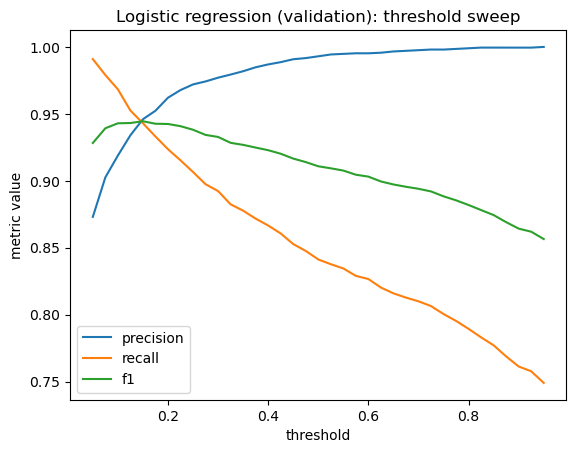

In [22]:
plt.figure()
plt.plot(sweep["threshold"], sweep["precision"], label="precision")
plt.plot(sweep["threshold"], sweep["recall"], label="recall")
plt.plot(sweep["threshold"], sweep["f1"], label="f1")
plt.xlabel("threshold")
plt.ylabel("metric value")
plt.title("Logistic regression (validation): threshold sweep")
plt.legend()
plt.show()

In [23]:
best_f1_row = sweep.sort_values("f1", ascending=False).iloc[0]
t_f1 = float(best_f1_row["threshold"])

RECALL_MIN = 0.80
eligible = sweep[sweep["recall"] >= RECALL_MIN]
if len(eligible) > 0:
    best_prec_row = eligible.sort_values("precision", ascending=False).iloc[0]
    t_recall = float(best_prec_row["threshold"])
else:
    t_recall = t_f1

print("Best-F1 threshold:", t_f1, "F1:", float(best_f1_row["f1"]))
print("Recall>=%.2f threshold:" % RECALL_MIN, t_recall)

Best-F1 threshold: 0.15 F1: 0.9444885011895321
Recall>=0.80 threshold: 0.725


## 5B.6.2 - Evaluate on Test (using chosen threshold)  

Evaluate on the test set **once** after choosing threshold on validation  

Show a confusion matrix so we can see which kind of errors dominate

In [24]:
p_te_s = logreg_safe.predict_proba(Xte_s)[:, 1]

test_f1 = evaluate_probs(yte, p_te_s, threshold=t_f1, label="logreg_safe_test_best_f1")
test_rc = evaluate_probs(yte, p_te_s, threshold=t_recall, label="logreg_safe_test_recall_policy")

pd.DataFrame([test_f1, test_rc])

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
0,logreg_safe_test_best_f1,0.150,0.902480,0.940922,0.945764,0.943337,0.95108,0.991941
1,logreg_safe_test_recall_policy,0.725,0.841658,0.996625,0.818290,0.898696,0.95108,0.991941


In [25]:
def show_confusion(y_true, p, t, title=""):
    yhat = (p >= t).astype(int)
    cm = confusion_matrix(y_true, yhat)
    print(title)
    print("threshold:", float(t))
    print("confusion matrix [[TN, FP],[FN, TP]]:")
    print(cm)

show_confusion(yte, p_te_s, t_f1, title="LogReg SAFE — test (best F1 threshold)")
show_confusion(yte, p_te_s, t_recall, title="LogReg SAFE — test (recall policy threshold)")

LogReg SAFE — test (best F1 threshold)
threshold: 0.15
confusion matrix [[TN, FP],[FN, TP]]:
[[ 267  150]
 [ 137 2389]]
LogReg SAFE — test (recall policy threshold)
threshold: 0.725
confusion matrix [[TN, FP],[FN, TP]]:
[[ 410    7]
 [ 459 2067]]


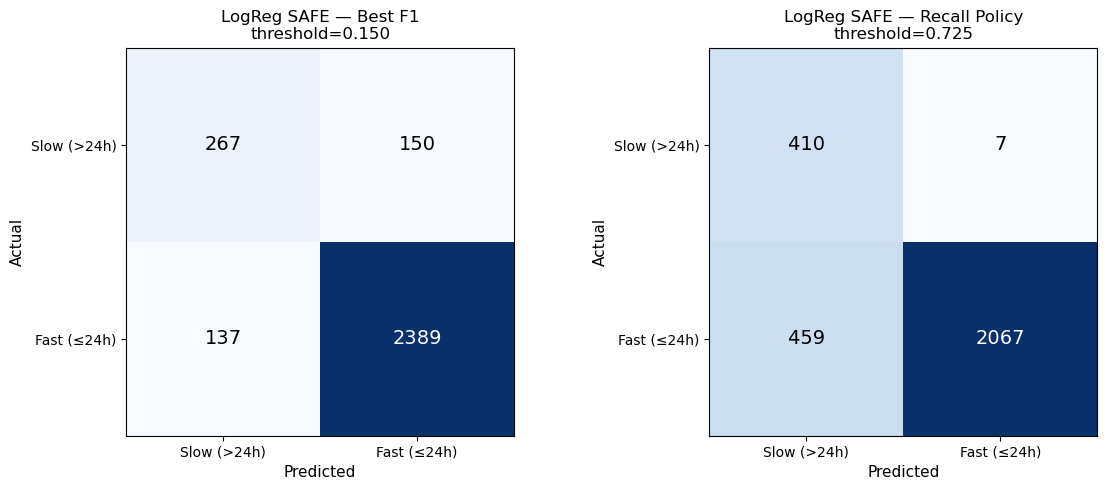

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, p, t, title="", ax=None):
    yhat = (p >= t).astype(int)
    cm = confusion_matrix(y_true, yhat)
    labels = ["Slow (>24h)", "Fast (≤24h)"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(f"{title}\nthreshold={t:.3f}", fontsize=12)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, color="white" if cm[i, j] > cm.max()/2 else "black")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(yte, p_te_s, t_f1,     title="LogReg SAFE — Best F1",       ax=axes[0])
plot_confusion(yte, p_te_s, t_recall, title="LogReg SAFE — Recall Policy",  ax=axes[1])
plt.tight_layout()
plt.show()

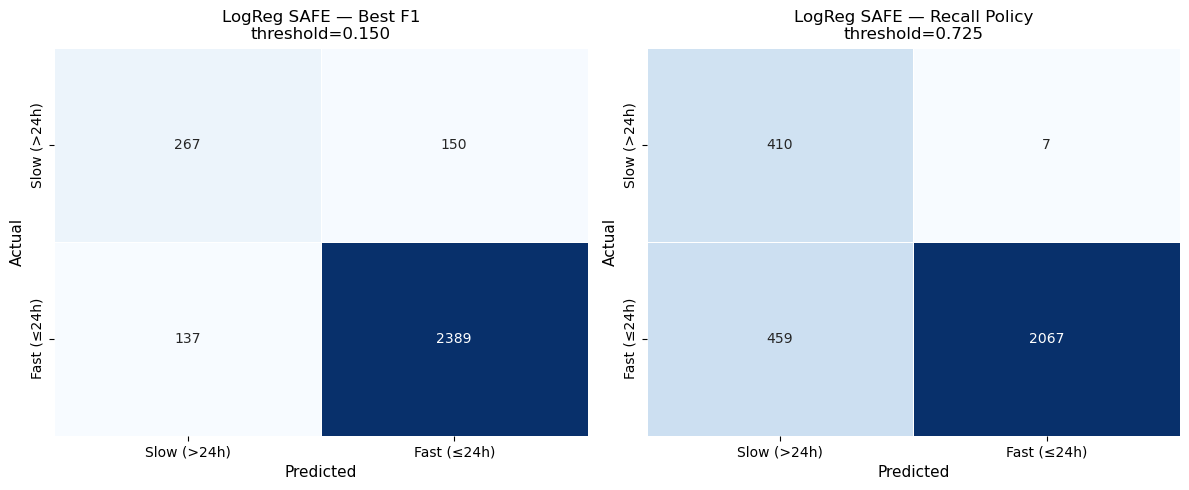

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, p, t, title="", ax=None):
    yhat = (p >= t).astype(int)
    cm = confusion_matrix(y_true, yhat)
    labels = ["Slow (>24h)", "Fast (≤24h)"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        ax=ax, cbar=False, linewidths=0.5
    )
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(f"{title}\nthreshold={t:.3f}", fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(yte, p_te_s, t_f1,    title="LogReg SAFE — Best F1",      ax=axes[0])
plot_confusion(yte, p_te_s, t_recall, title="LogReg SAFE — Recall Policy", ax=axes[1])
plt.tight_layout()
plt.show()

## 5B.7 - Interpret Logistic Regression Coefficients

Logistic regression is useful because it is interpretable.  

We will:
* Extract the post-preprocessing feature names (including one-hot columns)
* Show top positive coefficients (push probability toward 1)
* Show top negative coefficients (push probability toward 0)

Interpretation tips:  
* Coefficients are easiest to compare when features are standardized
* One-hot features represent "membership" in a category relative to the baseline of "not that category"
* Correlated features can dilute each other

In [28]:
# --- Coefficient inspection (SAFE logistic regression) ---

pre = logreg_safe.named_steps["pre"]
model = logreg_safe.named_steps["model"]

# Because we set verbose_feature_names_out=False in build_preprocessor,
# these names should be clean and readable.
feature_names = list(pre.get_feature_names_out())
coefs = model.coef_.ravel()

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

display(coef_df.sort_values("coef", ascending=False).head(15))
display(coef_df.sort_values("coef", ascending=True).head(15))

,feature,coef,abs_coef
20,agency_NYPD,5.392381,5.392381
34,complaint_topk_illegal parking,1.505942,1.505942
32,complaint_topk_heat/hot water,1.297886,1.297886
28,complaint_topk_blocked driveway,1.147587,1.147587
13,agency_DOB,0.838493,0.838493
11,agency_DEP,0.716192,0.716192
40,complaint_topk_traffic signal condition,0.708910,0.708910
17,agency_DPR,0.642439,0.642439
14,agency_DOE,0.604807,0.604807
35,complaint_topk_noise - residential,0.539254,0.539254


,feature,coef,abs_coef
8,n_requests,-5.603286,5.603286
19,agency_HPD,-3.209735,3.209735
39,complaint_topk_snow or ice,-1.781615,1.781615
15,agency_DOHMH,-1.190087,1.190087
21,agency_TLC,-1.185806,1.185806
10,agency_DCWP,-1.123102,1.123102
18,agency_DSNY,-0.839310,0.839310
33,complaint_topk_homeless person assistance,-0.763392,0.763392
29,complaint_topk_door/window,-0.677158,0.677158
41,complaint_topk_unsanitary condition,-0.671499,0.671499


## 5B.7.1 - Stability Check  

Refit multiple times on different random train splits, and count how often each feature lands in the top-K by absolute coefficient

In [29]:
def topk_feature_frequency(dfX, y, preprocessor, K=20, trials=12, train_frac=0.85):
    """Refit on multiple random train splits and count top-K coefficient appearances."""
    counts = {}
    for i in range(trials):
        Xtr, _, ytr_i, _ = train_test_split(
            dfX, y, test_size=(1 - train_frac), random_state=RANDOM_STATE + i, stratify=y
        )
        m = Pipeline([
            ("pre", preprocessor),
            ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced"))
        ])
        m.fit(Xtr, ytr_i)

        pre_i = m.named_steps["pre"]
        model_i = m.named_steps["model"]

        names = list(pre_i.get_feature_names_out())
        coefs = model_i.coef_.ravel()
        top = np.argsort(np.abs(coefs))[::-1][:K]

        for idx in top:
            counts[names[idx]] = counts.get(names[idx], 0) + 1

    out = pd.DataFrame({"feature": list(counts.keys()), "topk_count": list(counts.values())})
    out["topk_rate"] = out["topk_count"] / trials
    return out.sort_values(["topk_count", "feature"], ascending=[False, True])

stability = topk_feature_frequency(Xtr_s, ytr, pre_safe, K=20, trials=12, train_frac=0.85)
stability.head(25)


,feature,topk_count,topk_rate
9,agency_DCWP,12,1.000000
13,agency_DOB,12,1.000000
5,agency_DOHMH,12,1.000000
12,agency_DSNY,12,1.000000
2,agency_HPD,12,1.000000
0,agency_NYPD,12,1.000000
8,agency_TLC,12,1.000000
10,complaint_topk_blocked driveway,12,1.000000
7,complaint_topk_heat/hot water,12,1.000000
4,complaint_topk_illegal parking,12,1.000000


## 5B.8 - k-Nearest Neighbors Baseline (with dimensionality reduction)  

To make kNN feasible with one-hot encoded categoricals:  
* preprocess (scale + one-hot)
* reduce dimensionality with `TruncatedSVD`
* run kNN on the dense low-dimensional embedding

In [30]:
def make_knn_pipeline(preprocessor, n_components=30, k=25):
    return Pipeline([
        ("pre", preprocessor),
        ("svd", TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance")),
    ])

# Small tuning grid (keep runtime reasonable)
svd_grid = [20, 40]
k_grid = [5, 15, 35]

rows = []
for n_comp in svd_grid:
    for k in k_grid:
        pipe = make_knn_pipeline(pre_safe, n_components=n_comp, k=k)
        pipe.fit(Xtr_s, ytr)
        p = pipe.predict_proba(Xva_s)[:, 1]
        r = evaluate_probs(yva, p, threshold=0.5, label=f"knn_svd{n_comp}_k{k}")
        rows.append(r)

knn_val_results = pd.DataFrame(rows).sort_values(["f1", "avg_precision"], ascending=False)
knn_val_results

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
4,knn_svd40_k15,0.5,0.916072,0.946338,0.956453,0.951368,0.948383,0.988792
5,knn_svd40_k35,0.5,0.914713,0.943124,0.958432,0.950717,0.954468,0.991117
1,knn_svd20_k15,0.5,0.914713,0.945904,0.955265,0.950561,0.945787,0.988064
2,knn_svd20_k35,0.5,0.913014,0.942668,0.956849,0.949705,0.952766,0.990742
3,knn_svd40_k5,0.5,0.910975,0.945669,0.950911,0.948283,0.923518,0.980023
0,knn_svd20_k5,0.5,0.908936,0.943789,0.950515,0.947140,0.917597,0.978133


In [31]:
best_knn = knn_val_results.iloc[0]
best_label = best_knn["label"]
print("Best kNN config:", best_label)

parts = best_label.split("_")
best_ncomp = int(parts[1].replace("svd", ""))
best_k = int(parts[2].replace("k", ""))

knn = make_knn_pipeline(pre_safe, n_components=best_ncomp, k=best_k)
knn.fit(Xtr_s, ytr)

p_va_knn = knn.predict_proba(Xva_s)[:, 1]
sweep_knn = threshold_sweep(yva, p_va_knn)
best_f1_knn_row = sweep_knn.sort_values("f1", ascending=False).iloc[0]
t_knn = float(best_f1_knn_row["threshold"])

print("kNN best-F1 threshold on val:", t_knn, "F1:", float(best_f1_knn_row["f1"]))

Best kNN config: knn_svd40_k15
kNN best-F1 threshold on val: 0.37499999999999994 F1: 0.9515691592406044


In [32]:
p_te_knn = knn.predict_proba(Xte_s)[:, 1]
knn_test = evaluate_probs(yte, p_te_knn, threshold=t_knn, label=f"knn_test_{best_label}")

pd.DataFrame([knn_test])


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
0,knn_test_knn_svd40_k15,0.375,0.918111,0.931621,0.976247,0.953412,0.953543,0.989893


In [33]:
show_confusion(yte, p_te_knn, t_knn, title="kNN — test (best-F1 threshold)")

kNN — test (best-F1 threshold)
threshold: 0.37499999999999994
confusion matrix [[TN, FP],[FN, TP]]:
[[ 236  181]
 [  60 2466]]


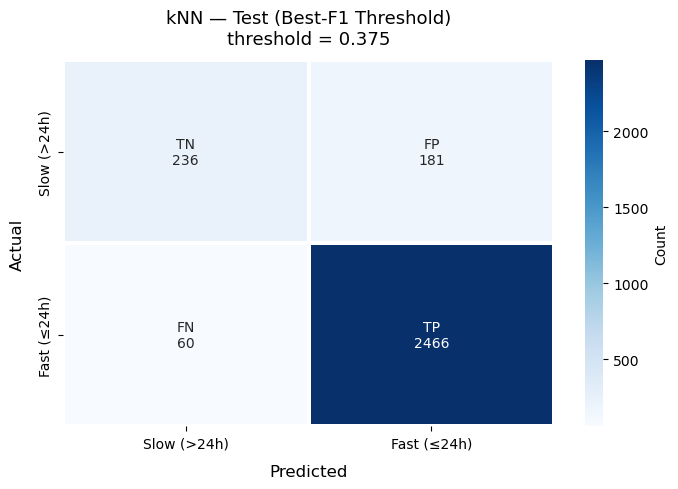

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_seaborn(y_true, p, t, title=""):
    yhat = (p >= t).astype(int)
    cm = confusion_matrix(y_true, yhat)
    
    labels = ["Slow (>24h)", "Fast (≤24h)"]
    annot = [
        [f"TN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
        [f"FN\n{cm[1,0]}", f"TP\n{cm[1,1]}"]
    ]

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=annot, fmt="", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        linewidths=1.5, linecolor="white",
        cbar_kws={"label": "Count"},
        ax=ax
    )
    ax.set_xlabel("Predicted", fontsize=12, labelpad=10)
    ax.set_ylabel("Actual", fontsize=12, labelpad=10)
    ax.set_title(f"{title}\nthreshold = {t:.3f}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()

plot_confusion_seaborn(yte, p_te_knn, t_knn, title="kNN — Test (Best-F1 Threshold)")

## 5B.9 - Compare Models (LogReg vs kNN)   

In [35]:
summary = pd.DataFrame([test_f1, test_rc, knn_test])
cols = ["label","threshold","accuracy","precision","recall","f1","roc_auc","avg_precision"]
summary[cols].sort_values("f1", ascending=False)


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
2,knn_test_knn_svd40_k15,0.375,0.918111,0.931621,0.976247,0.953412,0.953543,0.989893
0,logreg_safe_test_best_f1,0.150,0.902480,0.940922,0.945764,0.943337,0.951080,0.991941
1,logreg_safe_test_recall_policy,0.725,0.841658,0.996625,0.818290,0.898696,0.951080,0.991941


## 5B.10 - Show How Leakage Inflates Performance (SAFE vs ALL)  

This is deliberatly dangerous  
If ALL looks dramatically better than SAFE, probably included outcome revealers

In [36]:
# Train/evaluate Logistic Regression using ALL features (less strict drops).
# This is a deliberately dangerous experiment: if ALL looks dramatically better,
# you likely included outcome-revealing features.

logreg_all = Pipeline([
    ("pre", pre_all),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        class_weight="balanced",
    ))
])

logreg_all.fit(Xtr_a, ytr)

p_va_a = logreg_all.predict_proba(Xva_a)[:, 1]
sweep_all = threshold_sweep(yva, p_va_a)
t_all = float(sweep_all.sort_values("f1", ascending=False).iloc[0]["threshold"])

p_te_a = logreg_all.predict_proba(Xte_a)[:, 1]
all_test = evaluate_probs(yte, p_te_a, threshold=t_all, label="logreg_all_test_best_f1")

pd.DataFrame([
    {"label": "logreg_safe_test_best_f1", **{k: test_f1[k] for k in test_f1 if k != "label"}},
    {"label": "logreg_all_test_best_f1", **{k: all_test[k] for k in all_test if k != "label"}},
])


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision
0,logreg_safe_test_best_f1,0.15,0.902480,0.940922,0.945764,0.943337,0.951080,0.991941
1,logreg_all_test_best_f1,0.15,0.905199,0.942149,0.947743,0.944938,0.951111,0.991972


## 5B.11 - Deliverable: a short narrative

Write **8–12 bullets**. 

1) **Target definition:** What does “positive” mean in your experiment?  
2) **Positive rate:** How rare/common is the positive class? Why does that matter?  
3) **Best baseline:** Which model performed better *under your chosen threshold policy*?  
4) **Threshold policy:** Did you choose best-F1, a recall constraint, or something else? Why?  
5) **Errors:** Which error dominates (FP vs FN) and is that acceptable?  
6) **Interpretation:** Name 3–6 features that push probability up/down (logistic regression).  
7) **Stability:** Are the top features stable across re-splits? Which ones are unstable?  
8) **Leakage:** If ALL features looked better, what column(s) might be cheating?  
9) **Next steps:** What feature would you engineer next to improve performance?  
10) **Production note:** What would you monitor after deployment?

## My Narrative  

1. **Target definition:** A positive means that a 311 service request was resolved in 24 hours. 1 indicates fast resolution, 0 indicates longer than 24 hours or remains open.
2. **Positive rate:** 85.8% of the cases are positive. This makes the dataset highly skewed. The vast majority of the rows are positive. Therefore, the accuracy metric is not beneficial. In this situation, F1 becomes a better metric for model performance.
3. **Best baseline:** From 5B.8-9, kNN with SVD40/k=15 was the best model at F1=0.953. Logistic regression also had a high F1=0.943. However, kNN's recall of 0.976 vs. logistic regression's 0.946 makes it better at catching fast resolutions.
4. **Threshold policy:** Best F1 threshold was chosen, 0.375 for kNN and 0.15 for logistic regression. This balances precision and recall without strongly favoring either type.
5. **Errors:** False positives dominate. The kNN confusion matrix (5B.8) shows 181 FP vs. 60 FN. The model over predicts fast resolution. This is acceptable for 311 service management, since the cost of a false alarm (allocating resources to a case that takes longer than expected) is lower than missing a slow case that needed intervention.
6. **Interpretation:** In logistic regression, the features pushing probability up are:
    * `agency_NYPD` (5.39) - police complaints close quickly once dispatched
    * `complaint_topk_illegal_parking` (1.51) - easy case to resolve
    * `complaint_topk_blocked_driveway` (1.15) - easy case to resolve


   The features pushing probability down are:
    * `n_requests` (-5.60) - high volume locations get de prioritized
    * `agency_HPD` (-3.21) - housing complaints are slow
    * `complaint_topk_snow_or_ice` (-1.78) - seasonal and resource constrained
7. **Stability:** The main features were very stable, topk_rate = 1.0 across 12 re-splits.  A few (`complaint_topk_genearal`, `borough_norm_STATEN_ISLAND`, `complaint_topk_plumbing`) scored slow and should be considered unreliable.
8. **Leakage:** ALL outperformed SAFE by a very small margin. I would not consider there to be any meaningful leakage.
9. **Next steps:** Look into *complaint type x agency interaction*. The model currently treats these independently, but an HPD housing complaint behaves very differently than a DOB housing complaint.
10. **Production Note:** Monitor the positive rate drift. If the proportion of fast resolutions shift over time, the 0.375 threshold could become worse.